# Data Preprocessing Pipeline — Campus Building Dataset

## Purpose

This notebook defines the **shared preprocessing pipeline** used across all model training notebooks in this project. Rather than duplicating preprocessing logic in each training notebook, all data loading, cleaning, splitting, and transformation steps are centralised here.

Other notebooks (e.g. `01_baseline_model_MobileNetV2.ipynb`) import the outputs of this pipeline directly, ensuring consistency across experiments.

---

## What this notebook covers

| Step | Description |
|------|-------------|
| 1. Setup & Imports | Libraries, constants, and path configuration |
| 2. Load Dataset | Scan dataset folders, filter non-image files, build file/label lists |
| 3. Train / Val / Test Split | Stratified split to preserve class balance |
| 4. Preprocessing Function | EXIF correction, resize, and MobileNetV2 normalisation |
| 5. `tf.data` Pipelines | Efficient, batched pipelines for training and evaluation |
| 6. Verification | Visual sanity check — display a sample batch with labels |

---

## Dataset overview

- **Source:** Manually collected iPhone photos of LTU campus buildings
- **Classes:** Buildings 2, 3, 4, 5, 7, 8, 9, 10 (8 classes total)
- **Total images:** ~1,253
- **Target input size:** 224 × 224 pixels (required by MobileNetV2)

## 1. Setup & Imports

This section imports all required libraries and defines the global constants used throughout the pipeline.

### Constants

- **`IMAGE_SIZE`** — target resolution expected by MobileNetV2 (`224 × 224`)
- **`BATCH_SIZE`** — number of images per training batch; 32 is a common default that balances memory usage and gradient stability
- **`RANDOM_SEED`** — fixed seed for reproducibility across train/val/test splits
- **`DATASET_DIR`** — path to the root folder containing one sub-folder per building class
- **`IMAGE_EXTS`** — whitelist of valid image file extensions; used to skip macOS `.DS_Store` and other non-image files

In [1]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
# tf.config.set_visible_devices([], 'GPU')
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Image constants
IMAGE_SIZE  = (224, 224)   # MobileNetV2 expected input resolution
BATCH_SIZE  = 32           # Images per mini-batch

# Paths
DATASET_DIR = Path("../dataset")

# Valid image extensions (excludes macOS .DS_Store and other junk files)
IMAGE_EXTS  = {".jpg", ".jpeg", ".png", ".heic", ".bmp", ".tiff"}

print("Image size:        ", IMAGE_SIZE)
print("Batch size:        ", BATCH_SIZE)
print("Dataset directory: ", DATASET_DIR.resolve())

Image size:         (224, 224)
Batch size:         32
Dataset directory:  /Users/adamnajajreh/ltu/2. semester/DL/Capstone/dataset


## 2. Load Dataset

This section scans the dataset directory and builds two parallel lists:
- **`image_paths`** — absolute path to every valid image file
- **`labels`** — the corresponding integer class index (0–7)

A **class map** (`class_names`) is also created, which maps each integer index back to its human-readable building name (e.g. `0 → "2"`, `1 → "3"`, etc.). This mapping is used later when displaying predictions.

Non-image files such as macOS `.DS_Store` are skipped using the `IMAGE_EXTS` whitelist defined in the setup cell.

A summary is printed at the end showing the number of images per class and the total, so we can verify the dataset loaded correctly before moving on.

In [2]:
# Collect class names sorted numerically (e.g. ["2", "3", "4", ...])
class_names = sorted(
    [d.name for d in DATASET_DIR.iterdir() if d.is_dir()],
    key=int
)

# Map each class name to an integer index: {"2": 0, "3": 1, ...}
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

image_paths = []
labels      = []

for class_name in class_names:
    class_dir = DATASET_DIR / class_name
    for img_path in sorted(class_dir.iterdir()):
        if img_path.suffix.lower() not in IMAGE_EXTS:
            continue
        image_paths.append(str(img_path))
        labels.append(class_to_idx[class_name])

image_paths = np.array(image_paths)
labels      = np.array(labels)

# Print summary
print(f"{'Class':<10} {'Building':<12} {'Images':>6}")
print("-" * 30)
for idx, name in enumerate(class_names):
    count = np.sum(labels == idx)
    print(f"{idx:<10} Building {name:<4} {count:>6}")
print("-" * 30)
print(f"{'Total':<22} {len(labels):>6}")

Class      Building     Images
------------------------------
0          Building 2       171
1          Building 3       161
2          Building 4        83
3          Building 5       128
4          Building 7       174
5          Building 8       201
6          Building 9       179
7          Building 10      128
------------------------------
Total                    1225


## 3. Train / Validation / Test Split

The dataset is divided into three subsets:

| Split      | Proportion | Purpose                                              |
|------------|-----------|------------------------------------------------------|
| Train      | 70%       | Used to update model weights during training         |
| Validation | 15%       | Monitors performance after each epoch, guides early stopping |
| Test       | 15%       | Final unbiased evaluation — never seen during training |

### Why stratified splitting?

A standard random split could accidentally place most images of a minority class (e.g. Building 4 with only 83 images) into train, leaving very few for validation and test. **Stratified splitting** ensures each subset contains roughly the same class proportions as the full dataset.

### How it works

The split is done in two steps using `train_test_split` with `stratify`:
1. Split full dataset → **train (70%)** + temporary (30%)
2. Split temporary → **val (15%)** + **test (15%)**

In [3]:
# Step 1: split into train (70%) and a temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels,
    test_size=0.30,
    stratify=labels,
    random_state=RANDOM_SEED
)

# Step 2: split the temporary set evenly into val (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

# Print split summary
total = len(labels)
print(f"{'Split':<12} {'Images':>6}  {'Share':>6}")
print("-" * 26)
for name, y in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<12} {len(y):>6}  {len(y)/total*100:>5.1f}%")
print("-" * 26)
print(f"{'Total':<12} {total:>6}  100.0%")

# Per-class breakdown to verify stratification
print("\nPer-class split counts:")
print(f"{'Building':<12}", end="")
for split_name in ["Train", "Val", "Test"]:
    print(f"  {split_name:>6}", end="")
print()
print("-" * 36)
for idx, name in enumerate(class_names):
    print(f"Building {name:<4}", end="")
    for y in [y_train, y_val, y_test]:
        print(f"  {np.sum(y == idx):>6}", end="")
    print()

Split        Images   Share
--------------------------
Train           857   70.0%
Validation      184   15.0%
Test            184   15.0%
--------------------------
Total          1225  100.0%

Per-class split counts:
Building       Train     Val    Test
------------------------------------
Building 2        120      25      26
Building 3        113      24      24
Building 4         58      13      12
Building 5         89      19      20
Building 7        122      26      26
Building 8        141      30      30
Building 9        125      27      27
Building 10        89      20      19


## 4. Preprocessing Function

Before images can be fed into MobileNetV2, each image must go through three steps:

1. **EXIF orientation correction** — iPhone photos embed rotation metadata in their EXIF header rather than physically rotating the pixels. Without correcting this, images may appear sideways or upside-down when loaded by PIL or TensorFlow.

2. **Resize to 224 × 224** — MobileNetV2 expects a fixed input resolution of 224 × 224 pixels. All images are resized to this shape regardless of their original resolution.

3. **MobileNetV2 normalisation** — `tf.keras.applications.mobilenet_v2.preprocess_input` scales pixel values from the `[0, 255]` range to `[-1, 1]`, which is the range the pretrained MobileNetV2 weights were trained on. Using a different normalisation would degrade transfer learning performance.

### Why a `tf.py_function` wrapper?

TensorFlow's `tf.data` pipeline operates on tensors and compiled graph operations. PIL's `ImageOps.exif_transpose` is a Python-level operation and cannot run inside a standard `tf.data.Dataset.map()` call. Wrapping it in `tf.py_function` allows us to execute Python code within the pipeline while still benefiting from prefetching and parallel loading.

In [4]:
def load_and_preprocess(path, label):
    """
    Loads a single image from disk and prepares it for MobileNetV2.

    Steps:
      1. Read raw bytes and decode to an RGB tensor
      2. Apply EXIF orientation correction via PIL (handles iPhone rotation metadata)
      3. Resize to IMAGE_SIZE (224x224)
      4. Apply MobileNetV2 normalisation: scales pixels from [0, 255] to [-1, 1]

    Args:
        path  : tf.string tensor — absolute path to the image file
        label : tf.int64 tensor  — integer class index

    Returns:
        image : float32 tensor of shape (224, 224, 3), values in [-1, 1]
        label : unchanged int64 tensor
    """
    def _load_with_exif(path_bytes):
        # Decode the byte string to a Python str path
        img_path = path_bytes.numpy().decode("utf-8")
        with Image.open(img_path) as img:
            # Correct rotation encoded in EXIF metadata (common in iPhone photos)
            img = ImageOps.exif_transpose(img)
            img = img.convert("RGB")
            img = img.resize(IMAGE_SIZE, Image.BILINEAR)
        return np.array(img, dtype=np.float32)

    # Run the Python function inside the TF graph via py_function
    image = tf.py_function(_load_with_exif, [path], tf.float32)

    # Restore static shape so downstream layers know the tensor dimensions
    image.set_shape([IMAGE_SIZE[0], IMAGE_SIZE[1], 3])

    # Apply MobileNetV2 normalisation: [0, 255] -> [-1, 1]
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    return image, label

## 5. `tf.data` Pipelines

This section wraps the splits into `tf.data.Dataset` pipelines — TensorFlow's recommended way to feed data into a model efficiently.

### Pipeline steps per split

| Step | Train | Val | Test |
|------|-------|-----|------|
| Create dataset from paths & labels | yes | yes | yes |
| Shuffle | yes | no | no |
| Map (load & preprocess) | yes | yes | yes |
| Batch | yes | yes | yes |
| Prefetch | yes | yes | yes |

**Shuffle** is only applied to the training set. Shuffling validation and test sets would make no difference to evaluation results and wastes time.

**Prefetch** allows the CPU to prepare the next batch while the GPU processes the current one, reducing idle time between batches.

**`AUTOTUNE`** lets TensorFlow dynamically determine the optimal buffer sizes for prefetching and parallel mapping based on available hardware.

### How prefetch works

Without prefetch, data loading and training happen sequentially — the GPU sits idle while the CPU loads the next batch:

```
[load batch 1] → [train batch 1] → [load batch 2] → [train batch 2] → ...
```

With prefetch, they run in parallel — while the GPU trains on batch 1, the CPU is already loading batch 2 in the background:

```
[load batch 1] → [train batch 1]
                 [load batch 2] → [train batch 2]
                                  [load batch 3] → ...
```

By the time training finishes on one batch, the next is already ready. `AUTOTUNE` lets TensorFlow decide at runtime how many batches to prepare ahead based on available CPU and memory.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

def build_pipeline(paths, labels, shuffle=False):
    """
    Builds a tf.data.Dataset pipeline for a given split.

    Args:
        paths   : numpy array of image file path strings
        labels  : numpy array of integer class labels
        shuffle : if True, shuffles the dataset before batching (use for train only)

    Returns:
        A batched, prefetched tf.data.Dataset of (image, label) pairs.
    """
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        # Buffer size equal to dataset length ensures a fully random shuffle
        dataset = dataset.shuffle(buffer_size=len(paths), seed=RANDOM_SEED)

    dataset = dataset.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(AUTOTUNE)

    return dataset


train_ds = build_pipeline(X_train, y_train, shuffle=True)
val_ds   = build_pipeline(X_val,   y_val,   shuffle=False)
test_ds  = build_pipeline(X_test,  y_test,  shuffle=False)

print("Train batches:     ", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:      ", len(test_ds))

Train batches:      27
Validation batches: 6
Test batches:       6


2026-04-09 23:56:28.778521: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-04-09 23:56:28.778684: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-04-09 23:56:28.778690: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-04-09 23:56:28.778722: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-09 23:56:28.778732: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## 6. Verification — Visual Sanity Check

Before moving on to model training, it is important to visually confirm that the dataset was loaded and split correctly.

This section displays a grid of sample images:
- **Each row** corresponds to one building class
- **Each column** shows one randomly selected image from that class in the train, validation, and test splits respectively

Images are loaded directly from disk using PIL with EXIF correction applied, but **without** MobileNetV2 normalisation — this ensures the colours appear natural and are easy to inspect visually.

Things to check:
- Every building class appears in all three splits (confirms stratification worked)
- Images are displayed upright (confirms EXIF correction is working)
- Images look like the correct building for their label

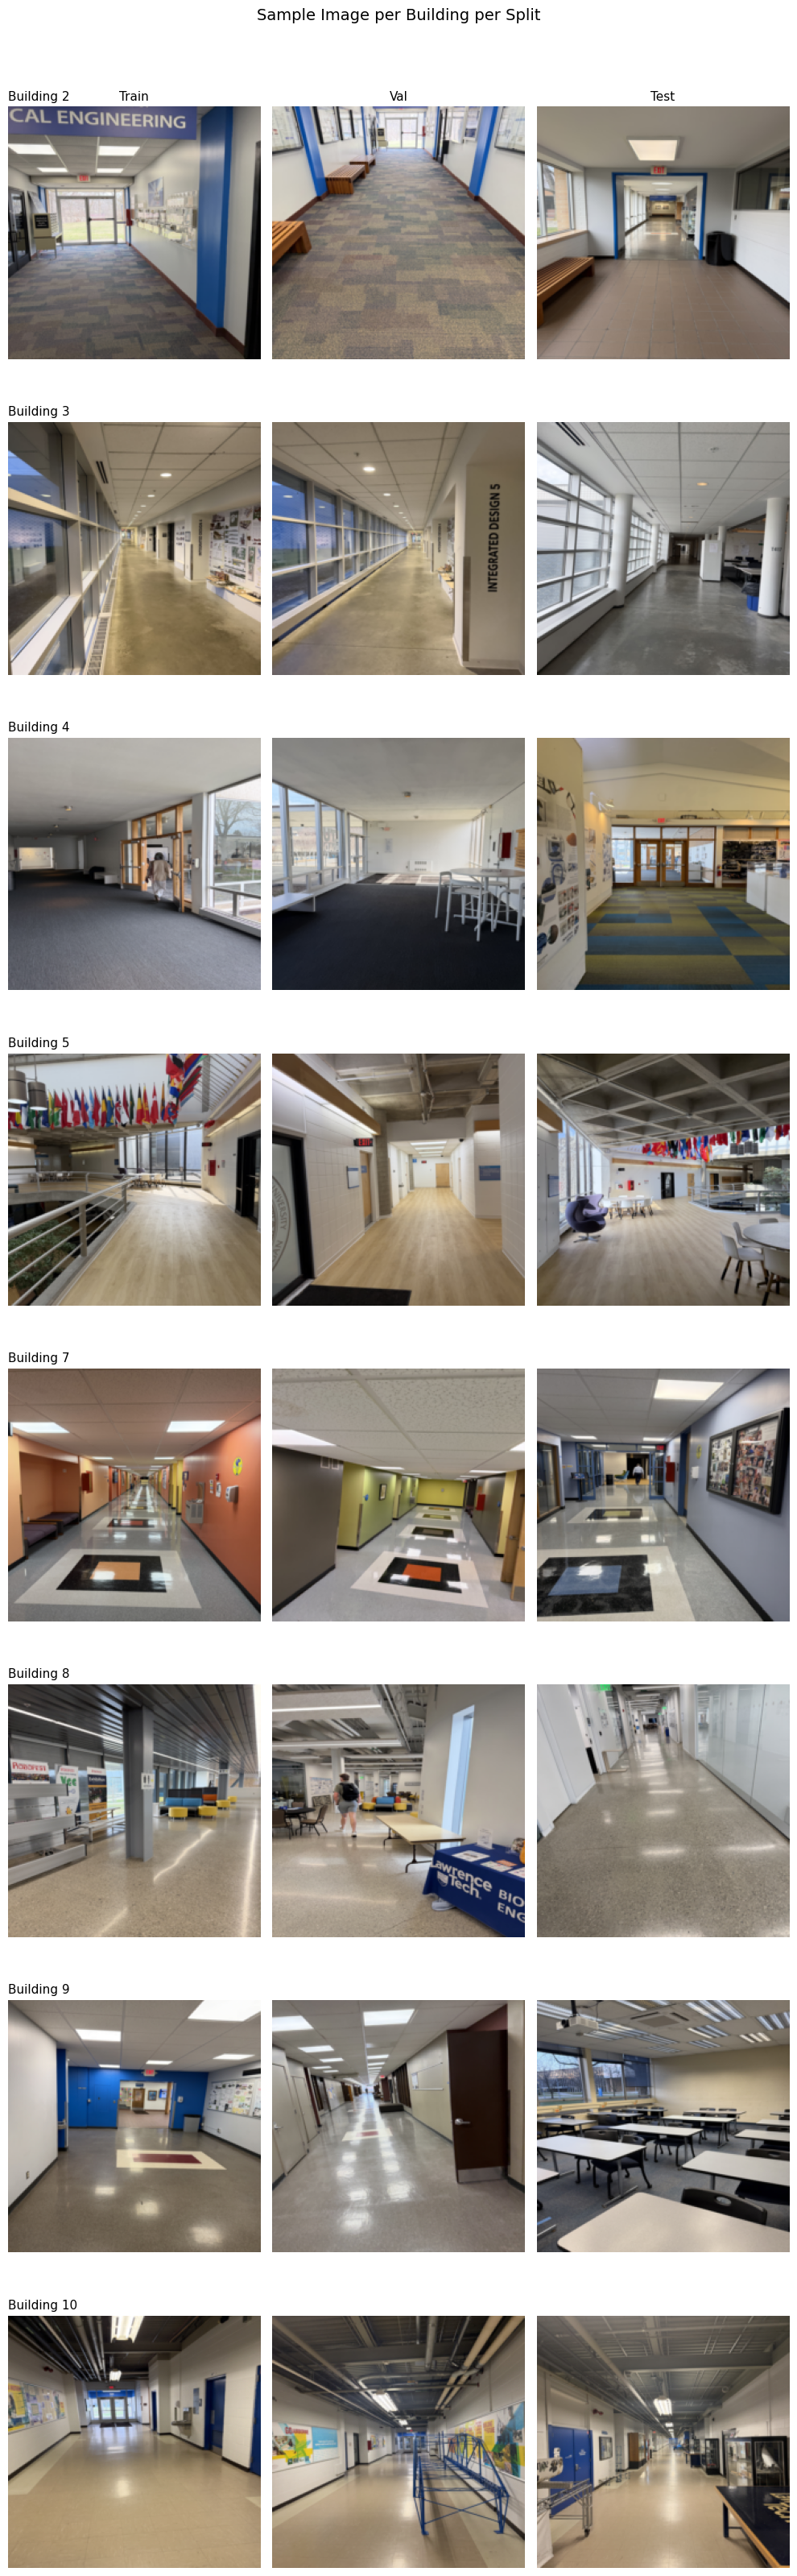

In [6]:
def load_display_image(path):
    """Load an image from disk with EXIF correction for display (no normalisation)."""
    with Image.open(path) as img:
        img = ImageOps.exif_transpose(img)
        img = img.convert("RGB")
        img = img.resize(IMAGE_SIZE, Image.BILINEAR)
    return img


splits = {
    "Train": (X_train, y_train),
    "Val":   (X_val,   y_val),
    "Test":  (X_test,  y_test),
}

fig, axes = plt.subplots(len(class_names), 3, figsize=(10, 4 * len(class_names)))

for row, (idx, name) in enumerate(enumerate(class_names)):
    for col, (split_name, (paths, lbls)) in enumerate(splits.items()):

        # Get all image paths belonging to this class in this split
        class_paths = paths[lbls == idx]

        # Randomly pick one
        chosen = random.choice(class_paths)
        img = load_display_image(chosen)

        axes[row, col].imshow(img)
        axes[row, col].axis("off")

        # Label first column with building name, label top row with split name
        if col == 0:
            axes[row, col].set_title(f"Building {name}", fontsize=11, loc="left")
        if row == 0:
            axes[row, col].set_title(f"{split_name}", fontsize=11, loc="center")

plt.suptitle("Sample Image per Building per Split", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
print("All available devices:")
for device in tf.config.list_physical_devices():
    print(f"  {device.device_type:<10} {device.name}")

All available devices:
  CPU        /physical_device:CPU:0
  GPU        /physical_device:GPU:0
